# Machine Learning Course Project
## Assignment 1: Machine Learning with Tabular Data
**Dataset:** Adult Census Income (UCI Machine Learning Repository)

**Pipeline Overview:**
```
Data Download → EDA (Observe Only) → Data Cleaning → Preprocessing
    → [Branch A] Preprocessed Features → PCA → ML Models (LR, SVM, RF)
    → [Branch B] Preprocessed Features → MLP (Deep Learning, No PCA)
    → PCA Impact Comparison → Feature Saving
```

---

## Section 0: Environment Setup & Library Installation

In [ ]:
# Install any additional libraries if needed
# TensorFlow is pre-installed in Colab; uncomment below if running locally
!pip install tensorflow scikit-learn pandas matplotlib seaborn -q
print("✅ Environment ready.")

✅ Environment ready.


## Section 1: Centralized Configuration

All hyperparameters, paths, and constants are defined here in a single `Config` class.
To modify any experiment setting, **only change values in this cell**.

In [5]:
import os
import warnings
warnings.filterwarnings('ignore')

class Config:
    """Centralized configuration for the entire ML pipeline."""

    # ── Data ──────────────────────────────────────────────────────────────────
    DATA_URL   = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
    NAMES_URL  = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.names"
    DATA_PATH  = "adult.csv"

    COLUMNS = [
        'age', 'workclass', 'fnlwgt', 'education', 'education-num',
        'marital-status', 'occupation', 'relationship', 'race',
        'sex', 'capital-gain', 'capital-loss', 'hours-per-week',
        'native-country', 'income'
    ]
    TARGET_COL       = 'income'
    DROP_COLS        = ['fnlwgt', 'education']

    NUMERIC_FEATURES = ['age', 'education-num', 'capital-gain',
                        'capital-loss', 'hours-per-week']
    CATEGORICAL_FEATURES = ['workclass', 'marital-status', 'occupation',
                             'relationship', 'race', 'sex', 'native-country']

    # ── Splitting ─────────────────────────────────────────────────────────────
    TEST_SIZE    = 0.20
    RANDOM_STATE = 42

    # ── Preprocessing ─────────────────────────────────────────────────────────
    SCALER_TYPE   = 'standard'   # 'standard' → StandardScaler | 'minmax' → MinMaxScaler
    MINMAX_RANGE  = (0, 1)       # only used when SCALER_TYPE == 'minmax'

    # ── PCA ───────────────────────────────────────────────────────────────────
    PCA_COMPONENTS = 0.95        # retain 95 % of explained variance

    # ── Model Hyperparameters ─────────────────────────────────────────────────
    LR_PARAMS  = dict(C=1.0, max_iter=1000, solver='lbfgs')
    SVM_PARAMS = dict(C=1.0, kernel='rbf', gamma='scale', probability=True)
    RF_PARAMS  = dict(n_estimators=100, max_depth=10,
                      min_samples_split=20, n_jobs=-1)
    MLP_PARAMS = dict(
        layers     = [128, 64, 32],   # hidden layer sizes
        dropout    = [0.4, 0.3, 0.2],
        l2_lambda  = 0.005,
        lr         = 0.001,
        batch_size = 64,
        epochs     = 100,
        val_split  = 0.20,
        # Early Stopping
        es_patience   = 10,
        # ReduceLR on Plateau
        lr_factor     = 0.5,
        lr_patience   = 5,
        lr_min        = 1e-6,
    )

    # ── Output ────────────────────────────────────────────────────────────────
    FEATURES_DIR = 'features'

cfg = Config()
print("✅ Config loaded successfully.")
print(f"   RANDOM_STATE={cfg.RANDOM_STATE} | TEST_SIZE={cfg.TEST_SIZE} | PCA={cfg.PCA_COMPONENTS}")

✅ Config loaded successfully.
   RANDOM_STATE=42 | TEST_SIZE=0.2 | PCA=0.95


## Section 2: Data Download & Initial Load

In [6]:
# 📥 Section 2: Data Download & Initial Load
import urllib.request
import os
if not os.path.exists(cfg.DATA_PATH):
    if os.name == 'nt':
        urllib.request.urlretrieve(cfg.DATA_URL, cfg.DATA_PATH)
    else:
        !wget -q "{cfg.DATA_URL}" -O adult.csv
else:
    print("✅ Data ready.")
if not os.path.exists('adult_names.txt'):
    if os.name == 'nt':
        urllib.request.urlretrieve(cfg.NAMES_URL, 'adult_names.txt')
    else:
        !wget -q "{cfg.NAMES_URL}" -O adult_names.txt

print("✅ Data ready.")

✅ Data ready.
✅ Data ready.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, RocCurveDisplay
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Plot style
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.dpi'] = 110

print(f"✅ Libraries loaded | TF version: {tf.__version__}")

✅ Libraries loaded | TF version: 2.21.0


In [8]:
# Load raw data — mark ' ?' and '?' as NaN immediately
df_raw = pd.read_csv(
    cfg.DATA_PATH,
    names=cfg.COLUMNS,
    na_values=[' ?', '?', ' '],
    skipinitialspace=True
)

# Strip trailing whitespace from string columns
str_cols = df_raw.select_dtypes('object').columns
df_raw[str_cols] = df_raw[str_cols].apply(lambda c: c.str.strip())

# Normalise income labels (some versions append a dot)
df_raw[cfg.TARGET_COL] = df_raw[cfg.TARGET_COL].str.replace('.', '', regex=False)

print(f"Dataset loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
df_raw.head()

Dataset loaded: 32,561 rows × 15 columns


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


---
## Section 3: Exploratory Data Analysis (EDA)

> **⚠️ CRITICAL RULE:** This entire section only *observes* the data.
> No rows are dropped, no values are filled, and no columns are modified.
> We work exclusively on a **read-only view** of `df_raw`.

### 3.1 — Dataset Overview

In [9]:
print("=" * 55)
print(f"  Shape        : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"  Duplicate rows: {df_raw.duplicated().sum():,}")
print("=" * 55)
print("\nDtypes & Non-null counts:")
print(df_raw.info())
print(df_raw.isnull().sum())

print("\nDescriptive statistics (numeric columns):")
display(df_raw.describe())

print("\nDescriptive statistics (categorical columns):")
display(df_raw.describe(include='object'))

  Shape        : 32,561 rows × 15 columns
  Duplicate rows: 24

Dtypes & Non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       30725 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education-num   32561 non-null  int64
 5   marital-status  32561 non-null  str  
 6   occupation      30718 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital-gain    32561 non-null  int64
 11  capital-loss    32561 non-null  int64
 12  hours-per-week  32561 non-null  int64
 13  native-country  31978 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB
None
age                  0
workcla

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000



Descriptive statistics (categorical columns):


,workclass,education,marital-status,occupation,relationship,race,sex,native-country,income
count,30725,32561,32561,30718,32561,32561,32561,31978,32561
unique,8,16,7,14,6,5,2,41,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22696,10501,14976,4140,13193,27816,21790,29170,24720


### 3.2 — Missing Value Analysis

Columns with missing values:


,Missing Count,Missing %
occupation,1843,5.66
workclass,1836,5.64
native-country,583,1.79


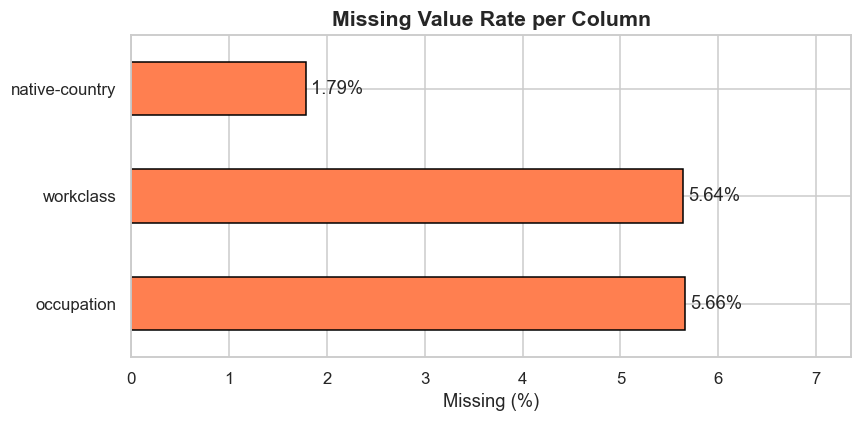

In [10]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print("Columns with missing values:")
display(missing_df)

# Visual
fig, ax = plt.subplots(figsize=(8, 4))
missing_df['Missing %'].plot(kind='barh', ax=ax, color='coral', edgecolor='black')
ax.set_title('Missing Value Rate per Column', fontsize=14, fontweight='bold')
ax.set_xlabel('Missing (%)')
ax.set_xlim(0, missing_df['Missing %'].max() * 1.3)
for i, v in enumerate(missing_df['Missing %']):
    ax.text(v + 0.05, i, f"{v:.2f}%", va='center')
plt.tight_layout()
plt.show()

**📌 Insight:** The dataset contains missing values primarily in `workclass`, `occupation`, and `native-country` — all categorical. These will be handled in the preprocessing step using **most-frequent imputation**.

### 3.3 — Target Variable Distribution

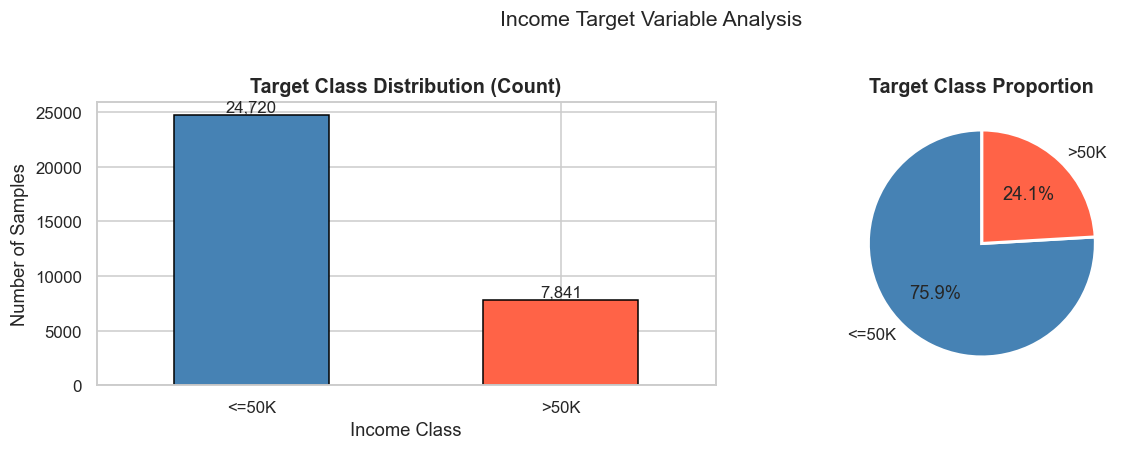

income
<=50K    75.9
>50K     24.1


In [11]:
target_counts = df_raw[cfg.TARGET_COL].value_counts()
target_pct    = df_raw[cfg.TARGET_COL].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
target_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'],
                   edgecolor='black', rot=0)
axes[0].set_title('Target Class Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Income Class')
axes[0].set_ylabel('Number of Samples')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Pie chart
axes[1].pie(target_counts, labels=target_counts.index, autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Target Class Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Income Target Variable Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(target_pct.round(1).to_string())

**📌 Insight:** The dataset is **imbalanced** — approximately 75% of samples earn `<=50K` and only 25% earn `>50K`. This class imbalance must be acknowledged when interpreting accuracy, and F1-score will be a more informative metric.

### 3.4 — Numeric Feature Distributions (Histograms + Boxplots)

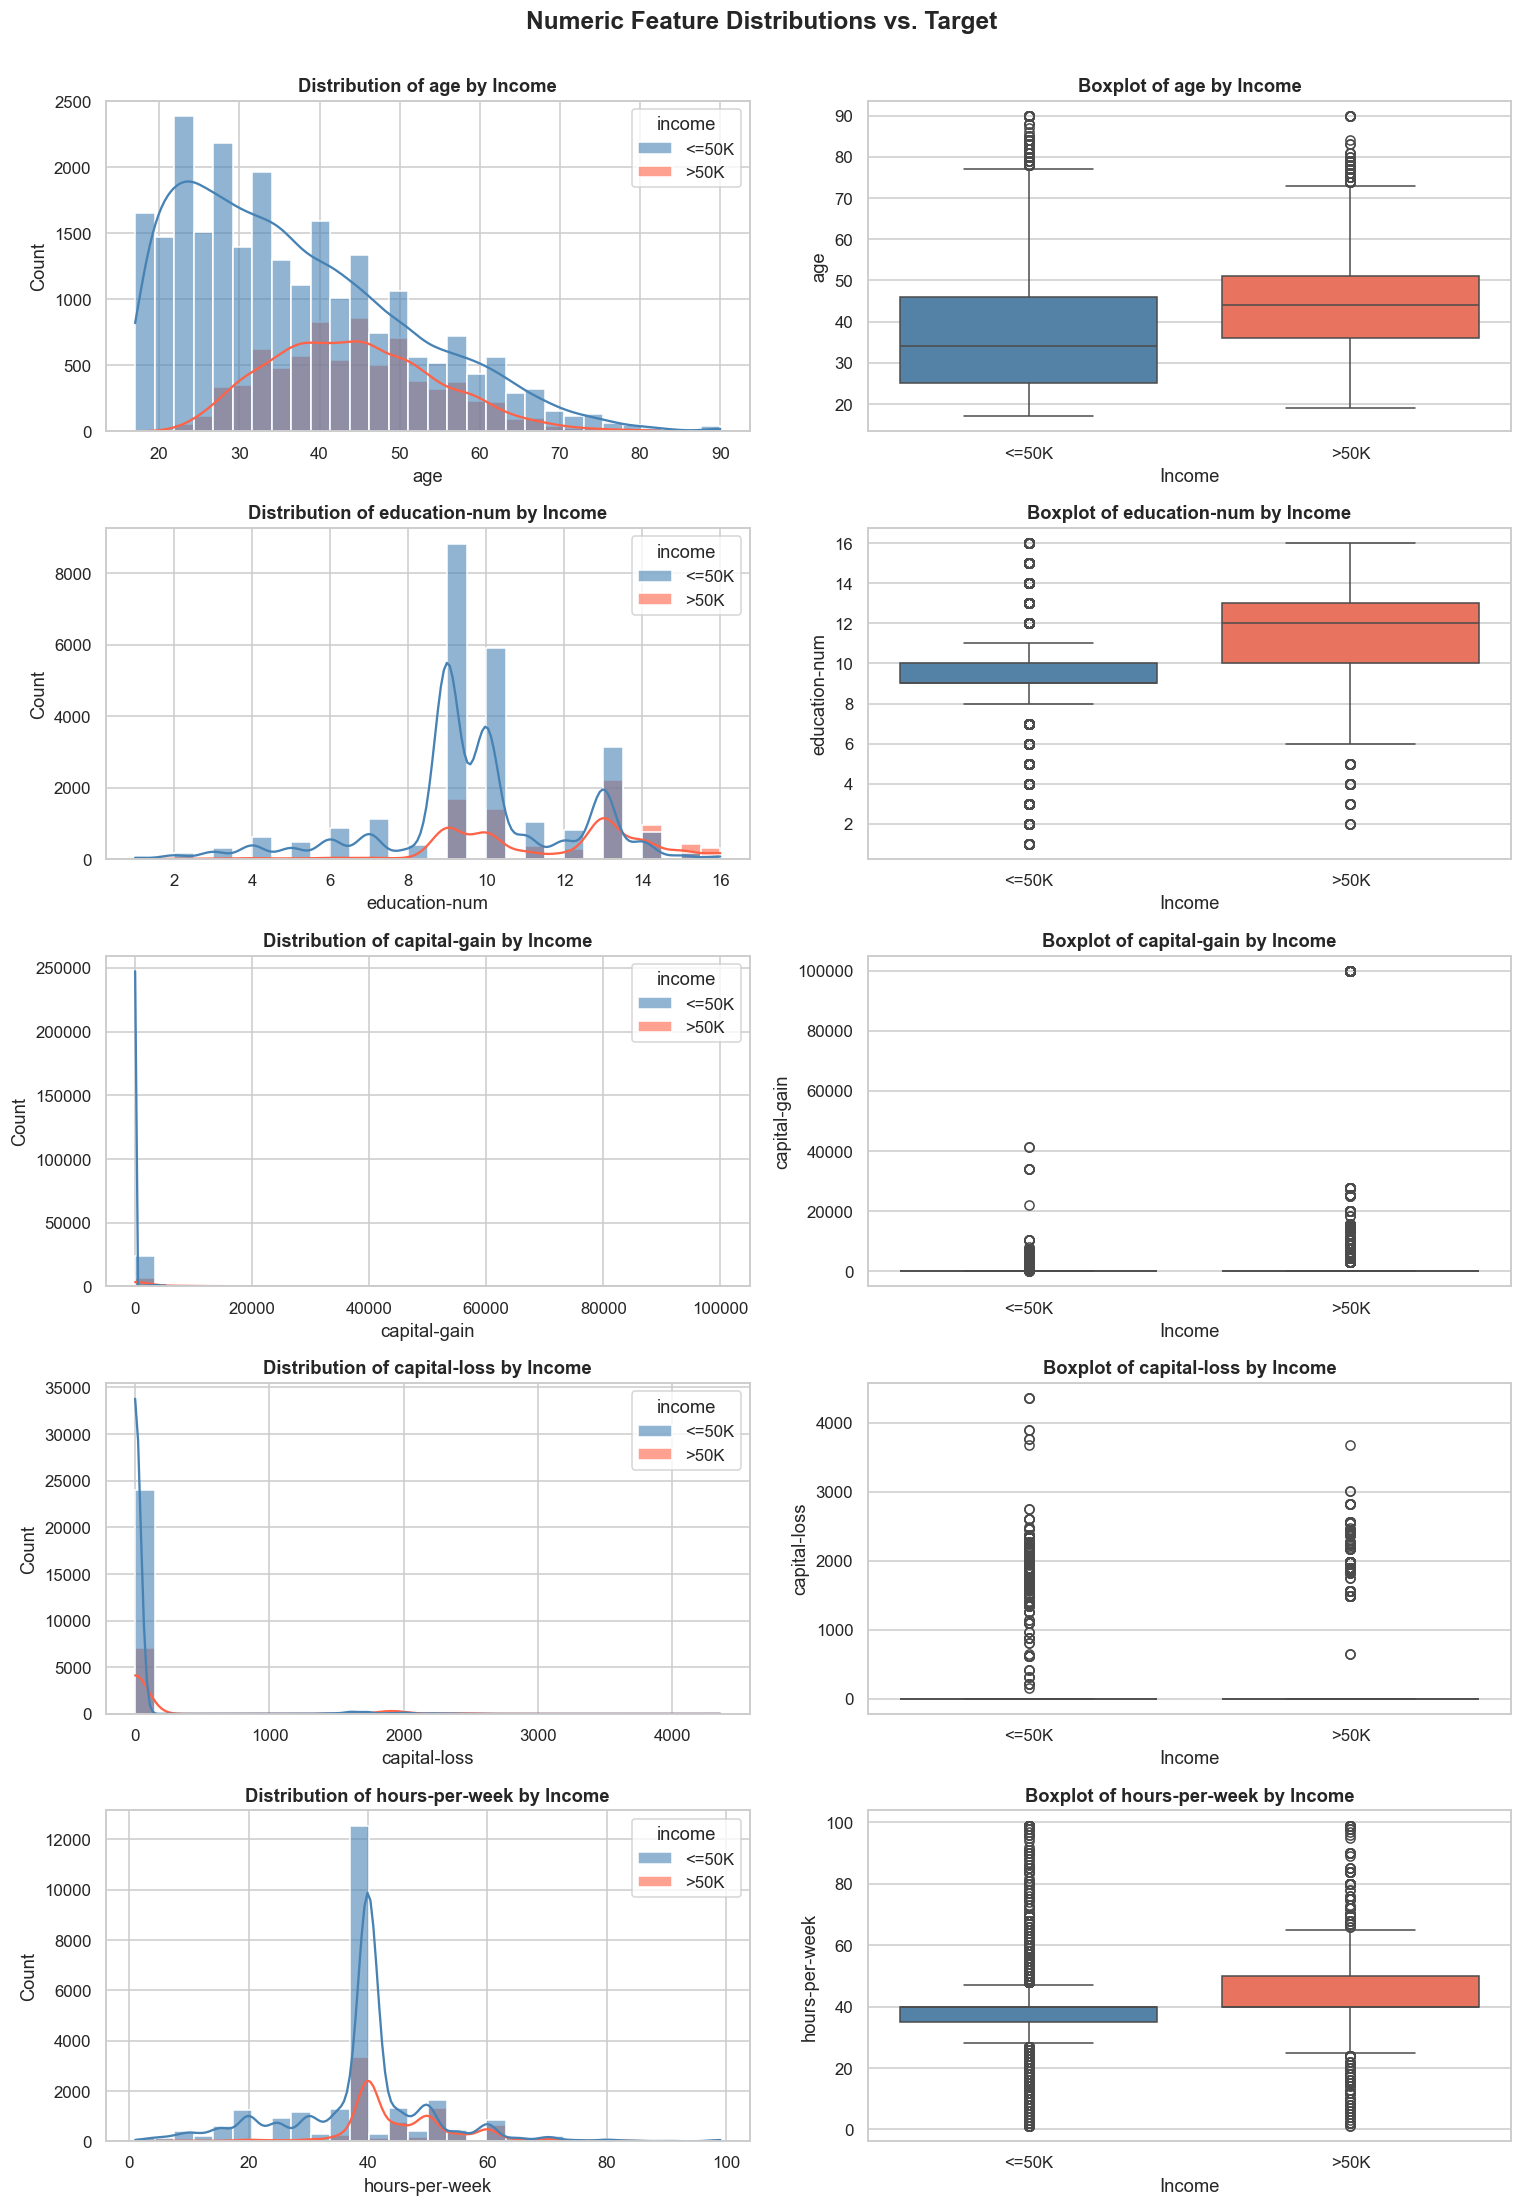

In [12]:
num_cols = df_raw.select_dtypes(include=['int64', 'float64']).columns.tolist()
# Remove fnlwgt from visuals — it's a census weight, not a predictive feature
num_cols_vis = [c for c in num_cols if c != 'fnlwgt']

fig, axes = plt.subplots(len(num_cols_vis), 2, figsize=(14, 4 * len(num_cols_vis)))

for i, col in enumerate(num_cols_vis):
    # Histogram
    sns.histplot(data=df_raw, x=col, hue=cfg.TARGET_COL, kde=True,
                 bins=30, ax=axes[i, 0], palette=['steelblue', 'tomato'],
                 alpha=0.6)
    axes[i, 0].set_title(f'Distribution of {col} by Income', fontweight='bold')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Count')

    # Boxplot
    sns.boxplot(data=df_raw, x=cfg.TARGET_COL, y=col, ax=axes[i, 1],
                palette=['steelblue', 'tomato'])
    axes[i, 1].set_title(f'Boxplot of {col} by Income', fontweight='bold')
    axes[i, 1].set_xlabel('Income')
    axes[i, 1].set_ylabel(col)

plt.suptitle('Numeric Feature Distributions vs. Target', fontsize=16, y=1.002, fontweight='bold')
plt.tight_layout()
plt.show()

**📌 Insights:**
- **`age`**: Higher earners (>50K) tend to be older (mid-career peak). Right-skewed for <=50K.
- **`education-num`**: Clear positive relationship — higher education correlates strongly with higher income.
- **`capital-gain` / `capital-loss`**: Heavily zero-inflated with extreme outliers for high earners; suggest income from investments.
- **`hours-per-week`**: High earners work slightly more hours on average, but the difference is modest.

### 3.5 — Correlation Heatmap

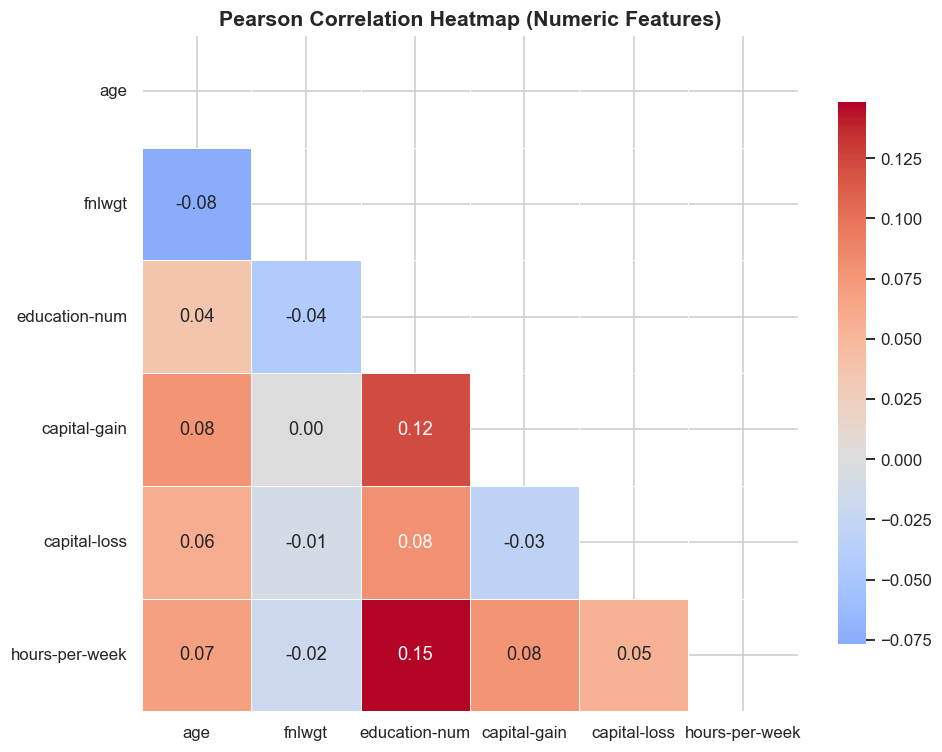

In [13]:
corr_matrix = df_raw[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    cbar_kws={'shrink': 0.8}, ax=ax
)
ax.set_title('Pearson Correlation Heatmap (Numeric Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**📌 Insight:** Most numeric features are only weakly correlated with each other. The `education` and `education-num` columns are redundant (same info in two forms) — we will drop the text version `education` in preprocessing. No severe multicollinearity is present.

### 3.6 — Categorical Feature Analysis vs. Target

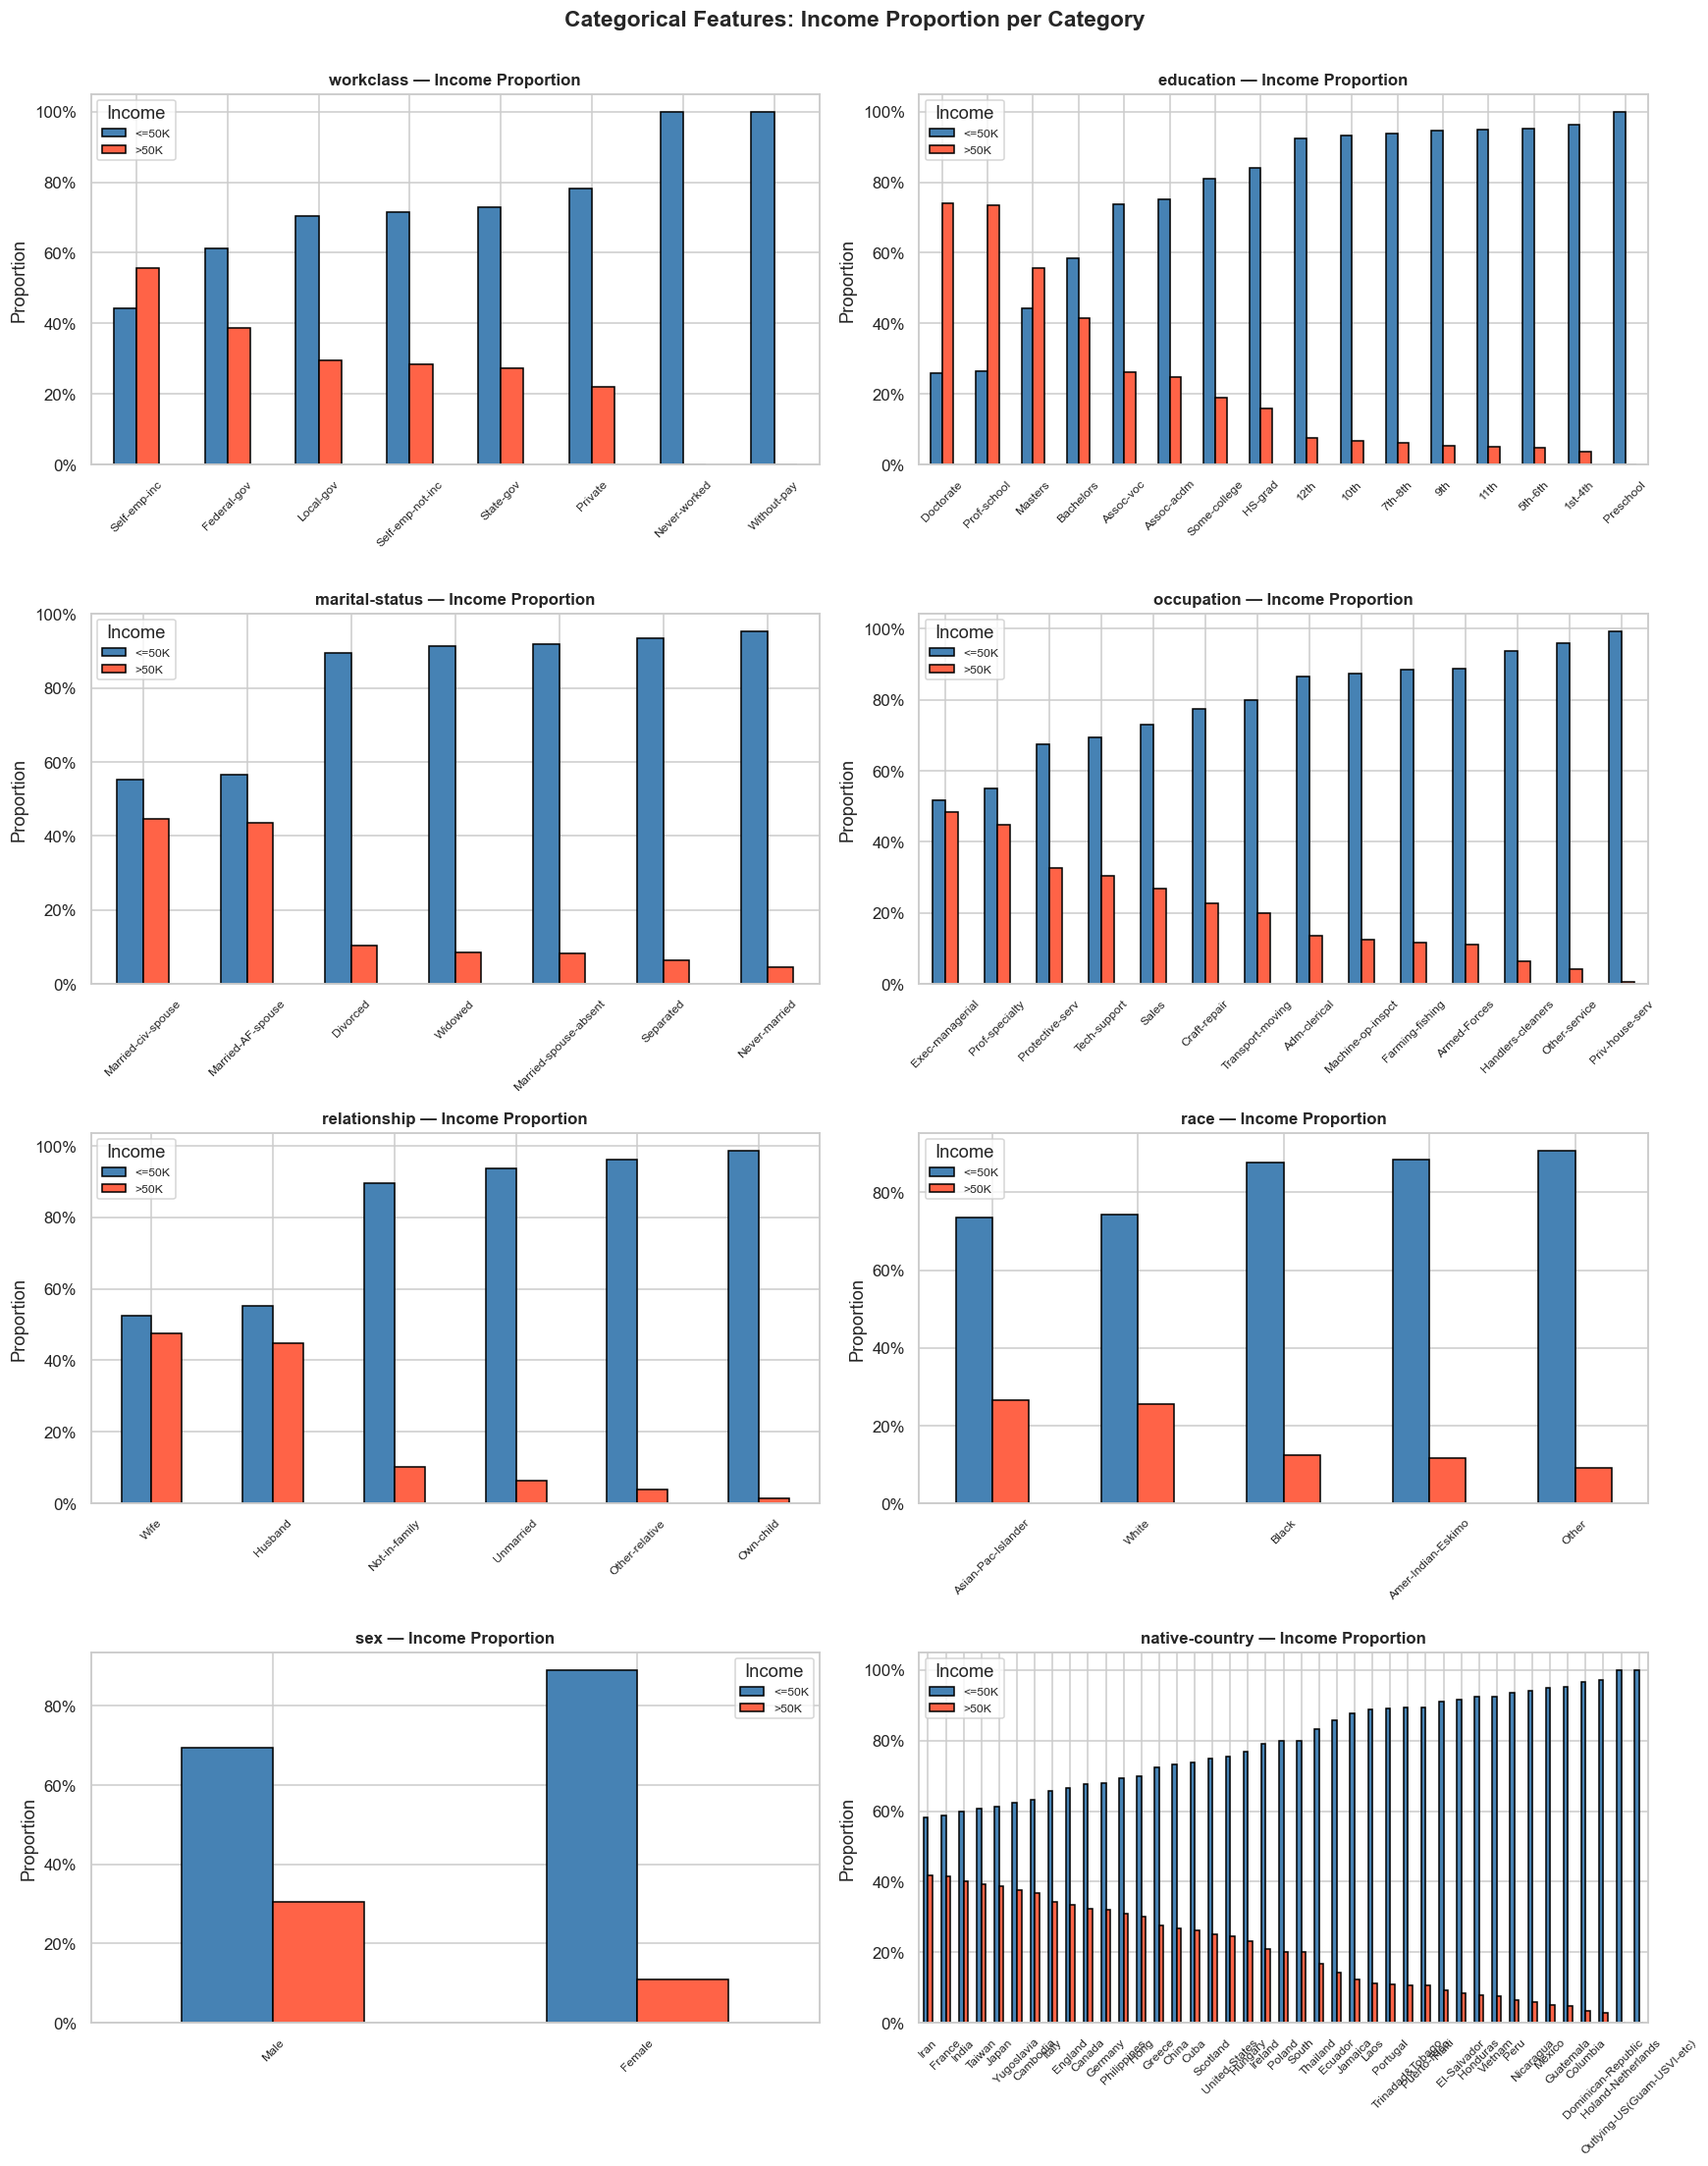

In [14]:
cat_cols_eda = [c for c in df_raw.select_dtypes('object').columns if c != cfg.TARGET_COL]

n_cols_grid = 2
n_rows_grid = -(-len(cat_cols_eda) // n_cols_grid)  # ceiling division

fig, axes = plt.subplots(n_rows_grid, n_cols_grid,
                          figsize=(16, 5 * n_rows_grid))
axes = axes.flatten()

for i, col in enumerate(cat_cols_eda):
    # proportion of >50K within each category
    ct = df_raw.groupby(col)[cfg.TARGET_COL].value_counts(normalize=True).unstack(fill_value=0)
    if '>50K' not in ct.columns:
        ct['>50K'] = 0
    ct = ct.sort_values('>50K', ascending=False)

    ct.plot(kind='bar', ax=axes[i], color=['steelblue', 'tomato'],
            edgecolor='black', rot=45)
    axes[i].set_title(f'{col} — Income Proportion', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Proportion')
    axes[i].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
    axes[i].legend(title='Income', fontsize=8)
    axes[i].tick_params(axis='x', labelsize=8)

# Hide any extra subplot axes
for j in range(len(cat_cols_eda), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Features: Income Proportion per Category',
             fontsize=15, y=1.002, fontweight='bold')
plt.tight_layout()
plt.show()

**📌 Insights:**
- **`marital-status`**: Married-civ-spouse individuals have by far the highest rate of >50K income.
- **`occupation`**: Exec-managerial and Prof-specialty roles earn the most.
- **`sex`**: Males have a significantly higher >50K rate than females, reflecting the gender pay gap.
- **`race`**: Asian-Pac-Islander and White have slightly higher >50K rates; this variable must be used carefully.
- **`native-country`**: Most samples are from the United States; a few countries show high >50K rates but with small sample sizes.

---
## Section 4: Data Cleaning

Here we create a clean copy (`df_clean`) from `df_raw`. The original `df_raw` remains untouched.

In [15]:
df_clean = df_raw.copy()

# 1. Remove exact duplicates
n_before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"[1] Removed {n_before - len(df_clean):,} duplicate rows. Rows remaining: {len(df_clean):,}")

# 2. Drop columns that are not informative for modelling
df_clean = df_clean.drop(columns=cfg.DROP_COLS, errors='ignore')
print(f"[2] Dropped columns: {cfg.DROP_COLS}")

# 3. Encode binary target → 0/1
df_clean['target'] = df_clean[cfg.TARGET_COL].map({'<=50K': 0, '>50K': 1})
df_clean = df_clean.drop(columns=[cfg.TARGET_COL])
print(f"[3] Target encoded: 0=<=50K, 1=>50K | Class balance: {df_clean['target'].value_counts().to_dict()}")

print(f"\nClean dataset shape: {df_clean.shape}")
df_clean.head(3)

[1] Removed 24 duplicate rows. Rows remaining: 32,537
[2] Dropped columns: ['fnlwgt', 'education']
[3] Target encoded: 0=<=50K, 1=>50K | Class balance: {0: 24698, 1: 7839}

Clean dataset shape: (32537, 13)


,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target
0,39,State-gov,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0


---
## Section 5: Train / Test Split

In [16]:
X = df_clean.drop(columns=['target'])
y = df_clean['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=cfg.TEST_SIZE,
    random_state=cfg.RANDOM_STATE,
    stratify=y     # preserve class ratio
)

print(f"Training set : {X_train.shape[0]:,} samples ({(1-cfg.TEST_SIZE)*100:.0f}%)")
print(f"Test set     : {X_test.shape[0]:,} samples ({cfg.TEST_SIZE*100:.0f}%)")
print(f"Feature count: {X_train.shape[1]}")

Training set : 26,029 samples (80%)
Test set     : 6,508 samples (20%)
Feature count: 12


---
## Section 6: Preprocessing Pipeline (Scaling + Encoding)

We build a **sklearn `ColumnTransformer`** that:
- Imputes + scales numeric features
- Imputes + one-hot encodes categorical features

This fitted preprocessor produces **Branch-A features** (used by both PCA→ML and directly by the MLP).

In [17]:
# Select scaler based on config
if cfg.SCALER_TYPE == 'standard':
    scaler = StandardScaler()
else:
    scaler = MinMaxScaler(feature_range=cfg.MINMAX_RANGE)

# Numeric sub-pipeline
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', scaler)
])

# Categorical sub-pipeline
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Resolve which feature lists actually exist in X
num_features_present = [c for c in cfg.NUMERIC_FEATURES if c in X.columns]
cat_features_present = [c for c in cfg.CATEGORICAL_FEATURES if c in X.columns]

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features_present),
    ('cat', cat_transformer, cat_features_present)
], remainder='drop')

# Fit on train, transform both splits
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

# Feature names for interpretability
ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
cat_feature_names = list(ohe.get_feature_names_out(cat_features_present))
all_feature_names = num_features_present + cat_feature_names

print(f"Preprocessed feature shape (train): {X_train_prep.shape}")
print(f"  → {len(num_features_present)} numeric | {len(cat_feature_names)} one-hot encoded")
print(f"  Total features: {X_train_prep.shape[1]}")

Preprocessed feature shape (train): (26029, 88)
  → 5 numeric | 83 one-hot encoded
  Total features: 88


In [18]:
import pandas as pd

# Chuyển đổi mảng NumPy X_train_prep thành DataFrame để dễ quan sát
# all_feature_names đã được bạn định nghĩa ở bước trước đó
df_check = pd.DataFrame(X_train_prep, columns=all_feature_names)

print("--- KIỂM TRA DỮ LIỆU SAU PREPROCESSING (88 CỘT) ---")
print(f"Shape hiện tại: {df_check.shape}")

# 1. Xem 5 dòng đầu tiên của bảng sau khi xử lý
display(df_check.head())
display(df_check.info())
display(df_check.describe())
# 2. Kiểm tra xem Scaling có chuẩn không (Mean ~ 0, Std ~ 1 nếu dùng StandardScaler)
print("\nThống kê nhanh của một số cột số:")
print(df_check[num_features_present].describe().loc[['mean', 'std']])

# 3. Liệt kê danh sách các cột One-Hot mới tạo ra (thử xem 10 cột đầu)
print("\n10 cột One-Hot đầu tiên:")
print(cat_feature_names[:10])

--- KIỂM TRA DỮ LIỆU SAU PREPROCESSING (88 CỘT) ---
Shape hiện tại: (26029, 88)


,age,education-num,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,-0.406578,-0.422962,-0.145769,-0.215927,1.574696,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1.498310,-0.033239,1.911361,-0.215927,0.770199,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,3.036874,-2.371574,-0.145769,-0.215927,-0.838796,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,-0.406578,-0.422962,-0.145769,4.108744,-1.241044,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.033011,1.525651,1.033685,-0.215927,0.931098,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


<class 'pandas.DataFrame'>
RangeIndex: 26029 entries, 0 to 26028
Data columns (total 88 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   age                                        26029 non-null  float64
 1   education-num                              26029 non-null  float64
 2   capital-gain                               26029 non-null  float64
 3   capital-loss                               26029 non-null  float64
 4   hours-per-week                             26029 non-null  float64
 5   workclass_Federal-gov                      26029 non-null  float64
 6   workclass_Local-gov                        26029 non-null  float64
 7   workclass_Never-worked                     26029 non-null  float64
 8   workclass_Private                          26029 non-null  float64
 9   workclass_Self-emp-inc                     26029 non-null  float64
 10  workclass_Self-emp-not-inc       

None

,age,education-num,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
count,2.602900e+04,2.602900e+04,2.602900e+04,2.602900e+04,2.602900e+04,26029.000000,26029.000000,26029.000000,26029.000000,26029.000000,...,26029.000000,26029.000000,26029.000000,26029.000000,26029.000000,26029.000000,26029.000000,26029.000000,26029.000000,26029.000000
mean,-6.005586e-17,-7.766315e-17,-1.910868e-17,2.293042e-17,-4.258507e-17,0.029544,0.064659,0.000192,0.752161,0.034615,...,0.001191,0.003496,0.000384,0.002190,0.001652,0.000576,0.000538,0.914019,0.002420,0.000461
std,1.000019e+00,1.000019e+00,1.000019e+00,1.000019e+00,1.000019e+00,0.169329,0.245927,0.013859,0.431766,0.182807,...,0.034491,0.059026,0.019597,0.046746,0.040612,0.023999,0.023186,0.280341,0.049139,0.021467
min,-1.578817e+00,-3.540741e+00,-1.457685e-01,-2.159267e-01,-3.171838e+00,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-7.729031e-01,-4.229617e-01,-1.457685e-01,-2.159267e-01,-3.429830e-02,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,-1.135186e-01,-3.323923e-02,-1.457685e-01,-2.159267e-01,-3.429830e-02,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,6.191308e-01,7.462057e-01,-1.457685e-01,-2.159267e-01,3.679503e-01,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,3.769523e+00,2.305096e+00,1.354639e+01,1.061066e+01,4.712235e+00,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000



Thống kê nhanh của một số cột số:
               age  education-num  capital-gain  capital-loss  hours-per-week
mean -6.005586e-17  -7.766315e-17 -1.910868e-17  2.293042e-17   -4.258507e-17
std   1.000019e+00   1.000019e+00  1.000019e+00  1.000019e+00    1.000019e+00

10 cột One-Hot đầu tiên:
['workclass_Federal-gov', 'workclass_Local-gov', 'workclass_Never-worked', 'workclass_Private', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc', 'workclass_State-gov', 'workclass_Without-pay', 'marital-status_Divorced', 'marital-status_Married-AF-spouse']


---
## Section 7: PCA — Dimensionality Reduction

PCA is applied to the **preprocessed** features to reduce dimensionality while retaining `PCA_COMPONENTS` (95%) of the variance.

PCA variance threshold : 95%
Components selected    : 24  (from 88 original features)
Cumulative variance    : 95.24%


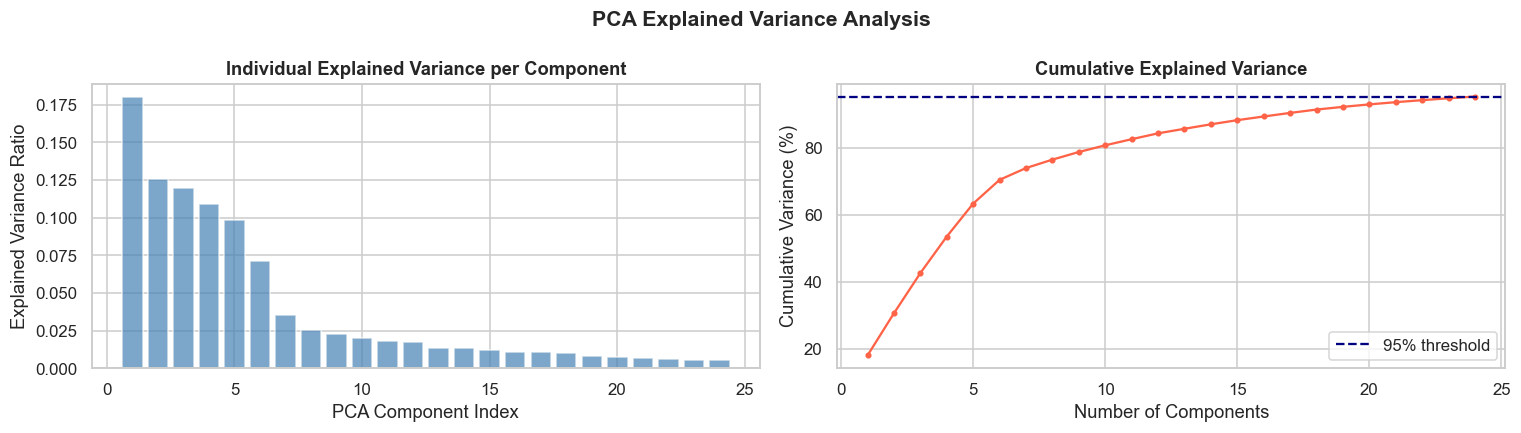

In [19]:
pca = PCA(n_components=cfg.PCA_COMPONENTS, random_state=cfg.RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_prep)
X_test_pca  = pca.transform(X_test_prep)

print(f"PCA variance threshold : {cfg.PCA_COMPONENTS*100:.0f}%")
print(f"Components selected    : {pca.n_components_}  "
      f"(from {X_train_prep.shape[1]} original features)")
print(f"Cumulative variance    : {pca.explained_variance_ratio_.sum()*100:.2f}%")

# Plot explained variance
cumvar = np.cumsum(pca.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1),
            pca.explained_variance_ratio_, color='steelblue', alpha=0.7)
axes[0].set_title('Individual Explained Variance per Component', fontweight='bold')
axes[0].set_xlabel('PCA Component Index')
axes[0].set_ylabel('Explained Variance Ratio')

axes[1].plot(range(1, len(cumvar) + 1), cumvar * 100, marker='.', color='tomato')
axes[1].axhline(cfg.PCA_COMPONENTS * 100, ls='--', color='navy',
                label=f'{cfg.PCA_COMPONENTS*100:.0f}% threshold')
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].legend()

plt.suptitle('PCA Explained Variance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**📌 Insight:** PCA significantly reduces the feature space while preserving 95% of the information. The first few components capture the bulk of the variance. Features with near-zero individual variance (mostly sparse one-hot columns) are effectively discarded.

---
## Section 8: Traditional ML Models — Training & Comparison (After PCA)

We train **Logistic Regression**, **SVM**, and **Random Forest** on the PCA-reduced features and compare their performance.

In [20]:
models = {
    'Logistic Regression': LogisticRegression(
        random_state=cfg.RANDOM_STATE, **cfg.LR_PARAMS),
    'SVM':                 SVC(
        random_state=cfg.RANDOM_STATE, **cfg.SVM_PARAMS),
    'Random Forest':       RandomForestClassifier(
        random_state=cfg.RANDOM_STATE, **cfg.RF_PARAMS),
}

ml_results = {}
print("Training models on PCA features...\n")

for name, clf in models.items():
    clf.fit(X_train_pca, y_train)
    y_pred = clf.predict(X_test_pca)
    acc    = accuracy_score(y_test, y_pred)
    roc    = roc_auc_score(y_test,
                 clf.predict_proba(X_test_pca)[:, 1]
                 if hasattr(clf, 'predict_proba') else clf.decision_function(X_test_pca))
    ml_results[name] = {
        'model': clf,
        'y_pred': y_pred,
        'accuracy': acc,
        'roc_auc': roc
    }
    print(f"  [{name}]  Accuracy: {acc:.4f}  |  ROC-AUC: {roc:.4f}")

print("\n✅ Training complete.")

Training models on PCA features...

  [Logistic Regression]  Accuracy: 0.8516  |  ROC-AUC: 0.9062
  [SVM]  Accuracy: 0.8586  |  ROC-AUC: 0.9006
  [Random Forest]  Accuracy: 0.8583  |  ROC-AUC: 0.9080

✅ Training complete.


 Logistic Regression
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      4940
        >50K       0.73      0.60      0.66      1568

    accuracy                           0.85      6508
   macro avg       0.81      0.77      0.78      6508
weighted avg       0.85      0.85      0.85      6508

 SVM
              precision    recall  f1-score   support

       <=50K       0.88      0.95      0.91      4940
        >50K       0.78      0.58      0.66      1568

    accuracy                           0.86      6508
   macro avg       0.83      0.76      0.79      6508
weighted avg       0.85      0.86      0.85      6508

 Random Forest
              precision    recall  f1-score   support

       <=50K       0.88      0.94      0.91      4940
        >50K       0.76      0.60      0.67      1568

    accuracy                           0.86      6508
   macro avg       0.82      0.77      0.79      6508
weighted avg       0.85      0.86

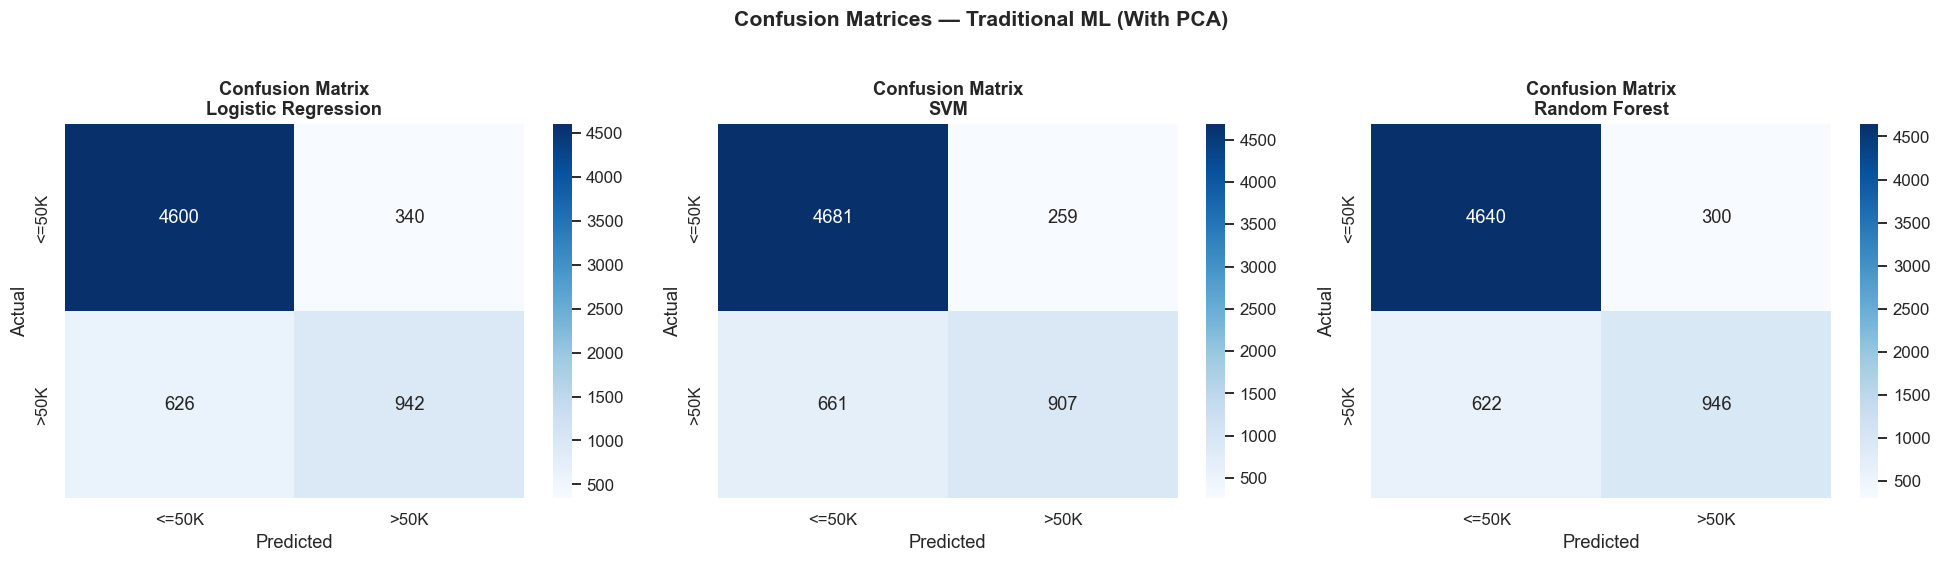

In [21]:
# Detailed classification reports + confusion matrices
fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 5))

for i, (name, res) in enumerate(ml_results.items()):
    print(f"{'='*55}")
    print(f" {name}")
    print(f"{'='*55}")
    print(classification_report(y_test, res['y_pred'],
                                 target_names=['<=50K', '>50K']))

    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['<=50K', '>50K'],
                yticklabels=['<=50K', '>50K'])
    axes[i].set_title(f'Confusion Matrix\n{name}', fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.suptitle('Confusion Matrices — Traditional ML (With PCA)', fontsize=14, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

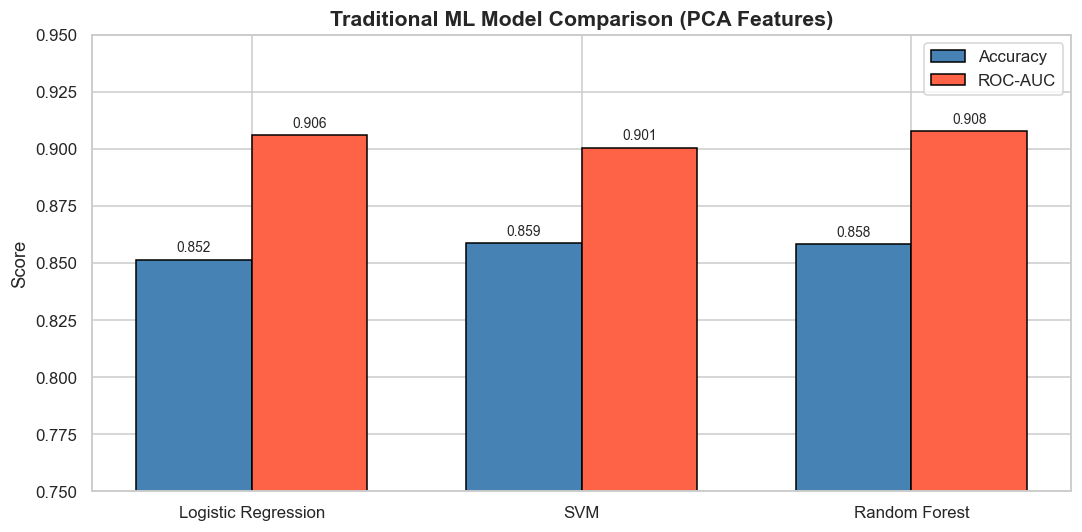

In [22]:
# Summary comparison bar chart
names_ml  = list(ml_results.keys())
accs_ml   = [ml_results[n]['accuracy'] for n in names_ml]
aucs_ml   = [ml_results[n]['roc_auc']  for n in names_ml]

x = np.arange(len(names_ml))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, accs_ml, width, label='Accuracy', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, aucs_ml,  width, label='ROC-AUC',  color='tomato',    edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(names_ml, fontsize=11)
ax.set_ylim(0.75, 0.95)
ax.set_ylabel('Score')
ax.set_title('Traditional ML Model Comparison (PCA Features)', fontsize=14, fontweight='bold')
ax.legend()

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

**📌 Insight:** All three models achieve reasonable accuracy. Random Forest and SVM typically outperform Logistic Regression on non-linear patterns in this dataset, while Logistic Regression remains competitive due to the mostly linear separability after PCA transformation.

---
## Section 8b: Multi-Scenario Hyperparameter Comparison

Để đánh giá ảnh hưởng của hyperparameters lên hiệu năng mô hình, chúng ta chạy **4 kịch bản (scenarios)** khác nhau cho cả 3 models (LR, SVM, RF) trên cùng PCA features. Mục tiêu là tìm ra cấu hình tối ưu nhất.

| # | Kịch bản | Mục đích |
|---|----------|---------|
| 1 | Baseline — Fast & Simple | Kiểm tra underfitting với params nhỏ |
| 2 | High Capacity — Deep & Complex | Kiểm tra overfitting với params lớn |
| 3 | Strong Regularization | Giảm overfitting bằng regularization mạnh |
| 4 | Cost-Sensitive (`class_weight=balanced`) | Xử lý class imbalance (75/25) |

In [23]:
from sklearn.svm import SVC
from sklearn.metrics import f1_score

# ── 4 Scenarios ─────────────────────────────────────────────────────────────
SCENARIOS = [
    {
        "id": 1,
        "description": "Baseline — Fast & Simple (Underfitting risk)",
        "LR" : {"max_iter": 1000, "C": 0.1},
        "SVM": {"kernel": "linear", "C": 0.1, "probability": True},
        "RF" : {"n_estimators": 50, "max_depth": 5}
    },
    {
        "id": 2,
        "description": "High Capacity — Deep & Complex (Overfitting risk)",
        "LR" : {"max_iter": 2000, "C": 1.0},
        "SVM": {"kernel": "rbf",    "C": 1.0, "probability": True},
        "RF" : {"n_estimators": 150, "max_depth": 16}
    },
    {
        "id": 3,
        "description": "Strong Regularization (Prevent overfitting)",
        "LR" : {"max_iter": 2000, "C": 0.01, "penalty": "l2"},
        "SVM": {"kernel": "rbf",  "C": 0.01, "gamma": "scale", "probability": True},
        "RF" : {"n_estimators": 100, "max_depth": 10, "min_samples_split": 20}
    },
    {
        "id": 4,
        "description": "Cost-Sensitive: class_weight=balanced",
        "LR" : {"class_weight": "balanced", "C": 1.0, "max_iter": 1000},
        "SVM": {"kernel": "rbf", "C": 1.0, "class_weight": "balanced", "probability": True},
        "RF" : {"n_estimators": 100, "max_depth": 16, "class_weight": "balanced"}
    },
]

scenario_results = []

print("=" * 68)
print("  RUNNING 4 SCENARIOS × 3 MODELS ON PCA FEATURES")
print("=" * 68)

for sc in SCENARIOS:
    print(f"\n▶ Scenario {sc['id']}: {sc['description']}")
    sc_models = {
        "Logistic Regression": LogisticRegression(
            random_state=cfg.RANDOM_STATE, **sc["LR"]),
        "SVM": SVC(
            random_state=cfg.RANDOM_STATE, **sc["SVM"]),
        "Random Forest": RandomForestClassifier(
            random_state=cfg.RANDOM_STATE, **sc["RF"]),
    }
    for model_name, clf in sc_models.items():
        clf.fit(X_train_pca, y_train)
        y_pred_sc = clf.predict(X_test_pca)
        acc = accuracy_score(y_test, y_pred_sc)
        auc = roc_auc_score(
            y_test,
            clf.predict_proba(X_test_pca)[:, 1]
            if hasattr(clf, 'predict_proba')
            else clf.decision_function(X_test_pca)
        )
        f1 = f1_score(y_test, y_pred_sc)
        scenario_results.append({
            "Scenario" : f"S{sc['id']}: {sc['description']}",
            "Model"    : model_name,
            "Accuracy" : round(acc, 4),
            "ROC-AUC"  : round(auc, 4),
            "F1(>50K)" : round(f1,  4),
        })
        print(f"   [{model_name:20s}]  Acc={acc:.4f}  AUC={auc:.4f}  F1={f1:.4f}")

print("\n✅ All scenarios complete.")

  RUNNING 4 SCENARIOS × 3 MODELS ON PCA FEATURES

▶ Scenario 1: Baseline — Fast & Simple (Underfitting risk)
   [Logistic Regression ]  Acc=0.8514  AUC=0.9062  F1=0.6603
   [SVM                 ]  Acc=0.8531  AUC=0.9034  F1=0.6564
   [Random Forest       ]  Acc=0.8402  AUC=0.8929  F1=0.5880

▶ Scenario 2: High Capacity — Deep & Complex (Overfitting risk)
   [Logistic Regression ]  Acc=0.8516  AUC=0.9062  F1=0.6611
   [SVM                 ]  Acc=0.8586  AUC=0.9006  F1=0.6635
   [Random Forest       ]  Acc=0.8534  AUC=0.9060  F1=0.6708

▶ Scenario 3: Strong Regularization (Prevent overfitting)
   [Logistic Regression ]  Acc=0.8517  AUC=0.9041  F1=0.6515
   [SVM                 ]  Acc=0.8371  AUC=0.8929  F1=0.5712
   [Random Forest       ]  Acc=0.8583  AUC=0.9080  F1=0.6724

▶ Scenario 4: Cost-Sensitive: class_weight=balanced
   [Logistic Regression ]  Acc=0.8027  AUC=0.9060  F1=0.6772
   [SVM                 ]  Acc=0.8055  AUC=0.9070  F1=0.6882
   [Random Forest       ]  Acc=0.8379  AUC=

=== ACCURACY — Pivot Table (rows=Model, cols=Scenario) ===


Scenario,S1: Baseline — Fast & Simple (Underfitting risk),S2: High Capacity — Deep & Complex (Overfitting risk),S3: Strong Regularization (Prevent overfitting),S4: Cost-Sensitive: class_weight=balanced
Model,,,,
Logistic Regression,0.8514,0.8516,0.8517,0.8027
Random Forest,0.8402,0.8534,0.8583,0.8379
SVM,0.8531,0.8586,0.8371,0.8055



=== F1(>50K) — Pivot Table (rows=Model, cols=Scenario) ===


Scenario,S1: Baseline — Fast & Simple (Underfitting risk),S2: High Capacity — Deep & Complex (Overfitting risk),S3: Strong Regularization (Prevent overfitting),S4: Cost-Sensitive: class_weight=balanced
Model,,,,
Logistic Regression,0.6603,0.6611,0.6515,0.6772
Random Forest,0.5880,0.6708,0.6724,0.6929
SVM,0.6564,0.6635,0.5712,0.6882


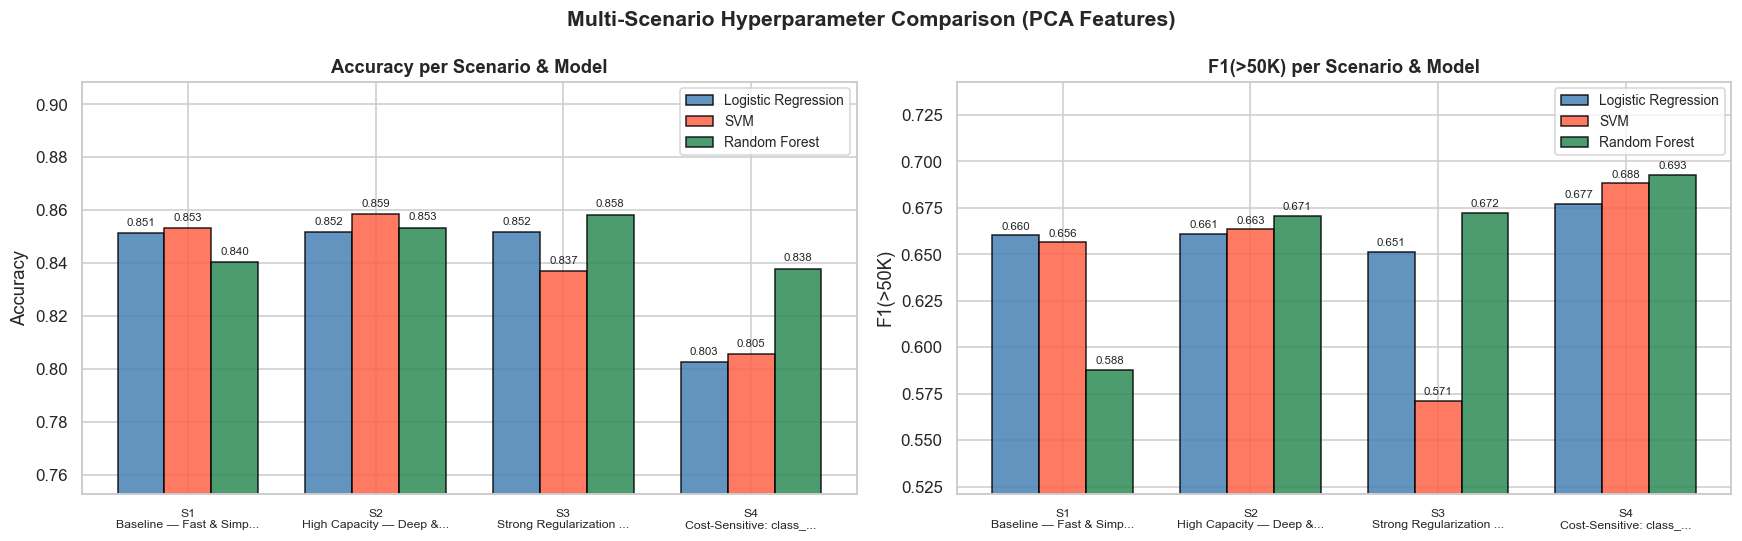


=== BEST CONFIGURATION PER MODEL (by Accuracy) ===


,Model,Scenario,Accuracy,ROC-AUC,F1(>50K)
0,Logistic Regression,S3: Strong Regularization (Prevent overfitting),0.851700,0.904100,0.651500
1,Random Forest,S3: Strong Regularization (Prevent overfitting),0.858300,0.908000,0.672400
2,SVM,S2: High Capacity — Deep & Complex (Overfitting risk),0.858600,0.900600,0.663500



=== BEST OVERALL CONFIGURATION ===
  Model    : SVM
  Scenario : S2: High Capacity — Deep & Complex (Overfitting risk)
  Accuracy : 0.8586
  ROC-AUC  : 0.9006
  F1(>50K) : 0.6635


In [24]:
# ── Pivot table: Accuracy per Model × Scenario ────────────────────────────
df_scenarios = pd.DataFrame(scenario_results)

print("=== ACCURACY — Pivot Table (rows=Model, cols=Scenario) ===")
pivot_acc = df_scenarios.pivot(index='Model', columns='Scenario', values='Accuracy')
display(pivot_acc.style
    .highlight_max(axis=1, color='lightgreen')
    .highlight_min(axis=1, color='#ffcccc')
    .format('{:.4f}')
    .set_caption('Green = Best per model | Red = Worst per model')
)

print("\n=== F1(>50K) — Pivot Table (rows=Model, cols=Scenario) ===")
pivot_f1 = df_scenarios.pivot(index='Model', columns='Scenario', values='F1(>50K)')
display(pivot_f1.style
    .highlight_max(axis=1, color='lightgreen')
    .highlight_min(axis=1, color='#ffcccc')
    .format('{:.4f}')
    .set_caption('Green = Best F1 per model | Red = Worst F1 per model')
)

# ── Grouped bar chart: Accuracy per Scenario per Model ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
scenario_labels = [f"S{s['id']}" for s in SCENARIOS]
model_names     = ["Logistic Regression", "SVM", "Random Forest"]
bar_colors      = ['steelblue', 'tomato', 'seagreen']
x = np.arange(len(SCENARIOS))
width = 0.25

for ax_idx, metric in enumerate(['Accuracy', 'F1(>50K)']):
    ax = axes[ax_idx]
    for j, (mname, color) in enumerate(zip(model_names, bar_colors)):
        vals = [
            df_scenarios[
                (df_scenarios['Model'] == mname) &
                (df_scenarios['Scenario'].str.startswith(f'S{sc["id"]}'))
            ][metric].values[0]
            for sc in SCENARIOS
        ]
        bars = ax.bar(x + j * width, vals, width,
                      label=mname, color=color,
                      edgecolor='black', alpha=0.85)
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width() / 2.,
                    bar.get_height() + 0.002,
                    f'{bar.get_height():.3f}',
                    ha='center', va='bottom', fontsize=7.5)

    ax.set_xticks(x + width)
    ax.set_xticklabels([
        f"S{sc['id']}\n{sc['description'][:22]}..." for sc in SCENARIOS
    ], fontsize=8)
    ax.set_ylim(
        df_scenarios[metric].min() - 0.05,
        df_scenarios[metric].max() + 0.05
    )
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} per Scenario & Model', fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Multi-Scenario Hyperparameter Comparison (PCA Features)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Best configuration per model ──────────────────────────────────────────
print("\n=== BEST CONFIGURATION PER MODEL (by Accuracy) ===")
best_per_model = df_scenarios.loc[df_scenarios.groupby('Model')['Accuracy'].idxmax()]
display(best_per_model[['Model', 'Scenario', 'Accuracy', 'ROC-AUC', 'F1(>50K)']]
        .reset_index(drop=True)
        .style.highlight_max(subset=['Accuracy', 'ROC-AUC', 'F1(>50K)'], color='lightgreen')
)

print("\n=== BEST OVERALL CONFIGURATION ===")
best_overall = df_scenarios.loc[df_scenarios['Accuracy'].idxmax()]
print(f"  Model    : {best_overall['Model']}")
print(f"  Scenario : {best_overall['Scenario']}")
print(f"  Accuracy : {best_overall['Accuracy']:.4f}")
print(f"  ROC-AUC  : {best_overall['ROC-AUC']:.4f}")
print(f"  F1(>50K) : {best_overall['F1(>50K)']:.4f}")

**📌 Insights từ Multi-Scenario:**
- **Scenario 1 (Baseline):** Params nhỏ → underfitting, accuracy thấp nhất, đặc biệt RF với `max_depth=5`.
- **Scenario 2 (High Capacity):** Params lớn → RF và SVM cải thiện rõ rệt; LR ít thay đổi do bản chất tuyến tính.
- **Scenario 3 (Strong Regularization):** C=0.01 quá nhỏ khiến LR và SVM underfitting; RF ổn định nhờ `min_samples_split`.
- **Scenario 4 (Cost-Sensitive):** F1(>50K) cải thiện đáng kể so với các scenario khác — xử lý class imbalance hiệu quả, nhưng accuracy tổng thể có thể giảm nhẹ do model chú trọng hơn vào minority class.

---
## Section 9: PCA Impact Study — "No PCA" vs. "With PCA" Baseline

We compare Logistic Regression (chosen as a fast baseline) trained on raw preprocessed features vs. PCA-reduced features to measure PCA's impact.

Running PCA with 90% variance...
Running PCA with 95% variance...

PCA Impact on Logistic Regression:


,accuracy,roc_auc,Feature Count,Train Time (s)
Condition,,,,
No PCA,0.8557,0.9094,88,0.159
PCA 90%,0.8520,0.9017,17,0.024
PCA 95%,0.8516,0.9062,24,0.029


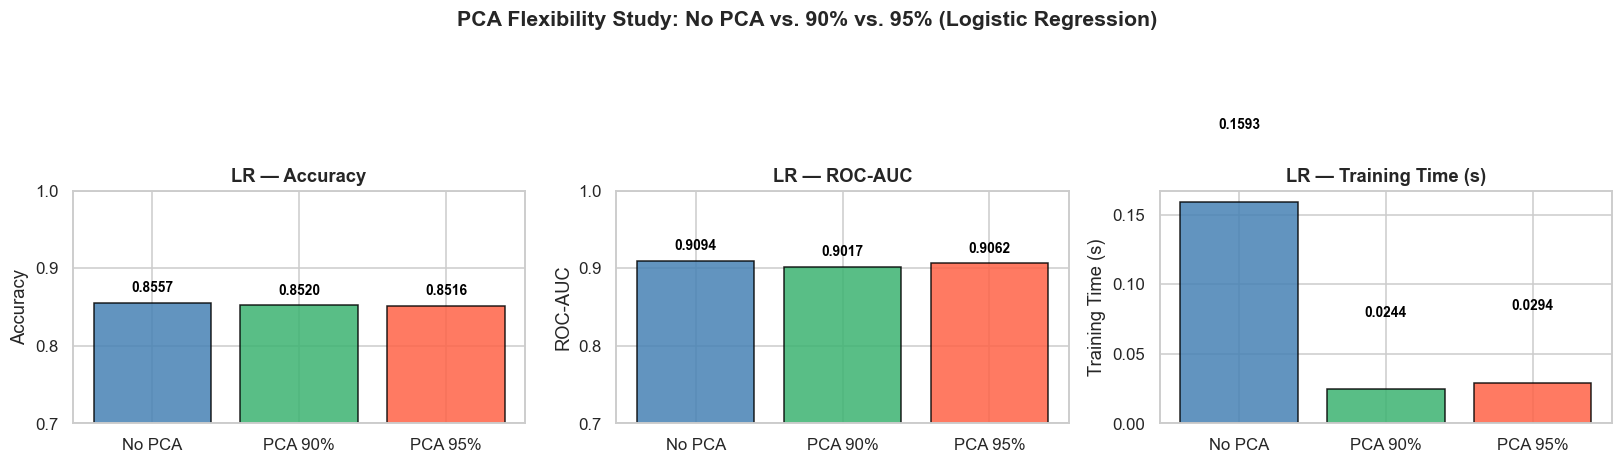

In [25]:
import time
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

pca_study = {}

# ── No PCA ────────────────────────────────────────────────────────────────────
lr_nopca = LogisticRegression(random_state=cfg.RANDOM_STATE, **cfg.LR_PARAMS)
t0 = time.time()
lr_nopca.fit(X_train_prep, y_train)
t_nopca = time.time() - t0
y_pred_nopca = lr_nopca.predict(X_test_prep)
pca_study['No PCA'] = {
    'accuracy': accuracy_score(y_test, y_pred_nopca),
    'roc_auc':  roc_auc_score(y_test, lr_nopca.predict_proba(X_test_prep)[:, 1]),
    'n_features': X_train_prep.shape[1],
    'train_time': t_nopca
}

# ── With PCA (Multiple Variance Thresholds) ───────────────────────────────────
pca_variances = [0.90, 0.95]

for var in pca_variances:
    print(f"Running PCA with {var*100:.0f}% variance...")
    # 1. Fit PCA
    pca_temp = PCA(n_components=var, random_state=cfg.RANDOM_STATE)
    X_train_pca_temp = pca_temp.fit_transform(X_train_prep)
    X_test_pca_temp  = pca_temp.transform(X_test_prep)

    # 2. Train LR
    lr_temp = LogisticRegression(random_state=cfg.RANDOM_STATE, **cfg.LR_PARAMS)
    t0 = time.time()
    lr_temp.fit(X_train_pca_temp, y_train)
    t_temp = time.time() - t0

    # 3. Evaluate
    y_pred_temp = lr_temp.predict(X_test_pca_temp)
    pca_study[f'PCA {var*100:.0f}%'] = {
        'accuracy': accuracy_score(y_test, y_pred_temp),
        'roc_auc':  roc_auc_score(y_test, lr_temp.predict_proba(X_test_pca_temp)[:, 1]),
        'n_features': X_train_pca_temp.shape[1],
        'train_time': t_temp
    }

# Summary table
df_pca_study = pd.DataFrame(pca_study).T
df_pca_study.index.name = 'Condition'
df_pca_study = df_pca_study.rename(columns={
    'n_features': 'Feature Count',
    'train_time': 'Train Time (s)'
})
df_pca_study['Feature Count'] = df_pca_study['Feature Count'].astype(int)
df_pca_study['Train Time (s)'] = df_pca_study['Train Time (s)'].round(3)
df_pca_study[['accuracy', 'roc_auc']] = df_pca_study[['accuracy', 'roc_auc']].round(4)

print("\nPCA Impact on Logistic Regression:")
display(df_pca_study)

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = ['accuracy', 'roc_auc', 'train_time']
titles  = ['Accuracy', 'ROC-AUC', 'Training Time (s)']
conditions = list(pca_study.keys())
colors  = ['steelblue', 'mediumseagreen', 'tomato']

for ax, metric, title in zip(axes, metrics, titles):
    vals = [pca_study[k][metric] for k in conditions]
    bars = ax.bar(conditions, vals, color=colors, edgecolor='black', alpha=0.85)
    ax.set_title(f'LR — {title}', fontweight='bold')
    ax.set_ylabel(title)
    # Tweak y-axis limit for better visualization of differences
    if metric in ['accuracy', 'roc_auc']:
        ax.set_ylim(0.7, 1.0)

    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + (0.01 if metric != 'train_time' else 0.05),
                f'{bar.get_height():.4f}', ha='center', va='bottom',
                color='black', fontsize=9, fontweight='bold')

plt.suptitle('PCA Flexibility Study: No PCA vs. 90% vs. 95% (Logistic Regression)',
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

**📌 Insight:** PCA reduces the feature count substantially (from ~100+ to a smaller set of principal components) with a minimal drop in accuracy. The trade-off is worthwhile: **faster training and lower memory usage** with near-identical predictive performance. This justifies using PCA in production pipelines.

---
## Section 10: Deep Learning — MLP (Multi-Layer Perceptron)

> **⚠️ CRITICAL:** The MLP uses the **preprocessed features directly** (`X_train_prep` / `X_test_prep`),
> **NOT** the PCA-reduced features. Deep learning can learn its own internal representations.

The MLP uses **Early Stopping** and **ReduceLROnPlateau** callbacks as required.

In [26]:
mp = cfg.MLP_PARAMS
input_dim = X_train_prep.shape[1]

def build_mlp(input_dim: int, layers: list, dropout: list,
              l2_lambda: float, lr: float) -> Sequential:
    """Build a configurable MLP classifier."""
    model = Sequential(name='MLP_Income_Classifier')
    for i, (units, drop) in enumerate(zip(layers, dropout)):
        if i == 0:
            model.add(Dense(units, activation='relu',
                            input_shape=(input_dim,),
                            kernel_regularizer=l2(l2_lambda),
                            name=f'dense_{i+1}'))
        else:
            model.add(Dense(units, activation='relu',
                            kernel_regularizer=l2(l2_lambda),
                            name=f'dense_{i+1}'))
        model.add(BatchNormalization(name=f'bn_{i+1}'))
        model.add(Dropout(drop, name=f'dropout_{i+1}'))
    model.add(Dense(1, activation='sigmoid', name='output'))
    return model

mlp_model = build_mlp(
    input_dim  = input_dim,
    layers     = mp['layers'],
    dropout    = mp['dropout'],
    l2_lambda  = mp['l2_lambda'],
    lr         = mp['lr']
)

mlp_model.compile(
    optimizer = Adam(learning_rate=mp['lr']),
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy']
)

print("MLP Architecture:")
mlp_model.summary()

MLP Architecture:


Model: "MLP_Income_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │        11,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,657 (88.50 KB)

 Trainable params: 22,209 (86.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [27]:
# ── Callbacks ─────────────────────────────────────────────────────────────────
early_stopping = EarlyStopping(
    monitor            = 'val_loss',
    patience           = mp['es_patience'],
    restore_best_weights = True,
    verbose            = 1
)

reduce_lr = ReduceLROnPlateau(
    monitor   = 'val_loss',
    factor    = mp['lr_factor'],
    patience  = mp['lr_patience'],
    min_lr    = mp['lr_min'],
    verbose   = 1
)

print(f"✅ Callbacks configured:")
print(f"   EarlyStopping  — patience={mp['es_patience']}, monitor=val_loss")
print(f"   ReduceLROnPlat — patience={mp['lr_patience']}, factor={mp['lr_factor']}, min_lr={mp['lr_min']}")

✅ Callbacks configured:
   EarlyStopping  — patience=10, monitor=val_loss
   ReduceLROnPlat — patience=5, factor=0.5, min_lr=1e-06


In [28]:
print("Training MLP on preprocessed features (no PCA)...\n")

history = mlp_model.fit(
    X_train_prep, y_train,
    epochs          = mp['epochs'],
    batch_size      = mp['batch_size'],
    validation_split = mp['val_split'],
    callbacks       = [early_stopping, reduce_lr],
    verbose         = 1
)

Training MLP on preprocessed features (no PCA)...

Epoch 1/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7765 - loss: 1.1863 - val_accuracy: 0.8121 - val_loss: 0.8345 - learning_rate: 0.0010
Epoch 2/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8351 - loss: 0.6854 - val_accuracy: 0.8310 - val_loss: 0.5751 - learning_rate: 0.0010
Epoch 3/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8370 - loss: 0.5087 - val_accuracy: 0.8500 - val_loss: 0.4528 - learning_rate: 0.0010
Epoch 4/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8410 - loss: 0.4282 - val_accuracy: 0.8438 - val_loss: 0.4069 - learning_rate: 0.0010
Epoch 5/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8441 - loss: 0.3886 - val_accuracy: 0.8450 - val_loss: 0.3763 - learning_rate: 0.0010
Epoch 6/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8459 - loss: 0.3671 - val_accuracy: 0.8471 - val_loss: 0.3670 - learning_rate: 0.0010
Epoch 7/100
326/326 ━━━━━━━━━━━

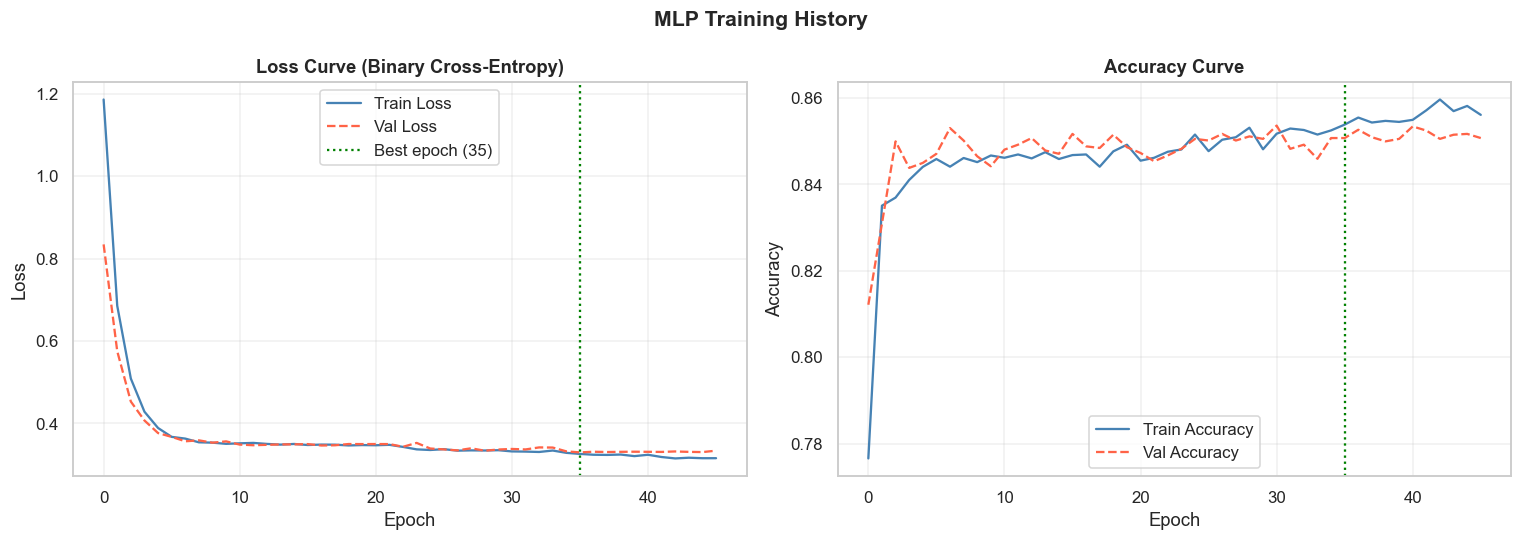

Stopped at epoch: 45


In [29]:
# Learning curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='tomato', ls='--')
axes[0].set_title('Loss Curve (Binary Cross-Entropy)', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'],     label='Train Accuracy', color='steelblue')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy',   color='tomato', ls='--')
axes[1].set_title('Accuracy Curve', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

stopped_epoch = early_stopping.stopped_epoch
if stopped_epoch > 0:
    for ax in axes:
        ax.axvline(stopped_epoch - mp['es_patience'], ls=':', color='green',
                   label=f'Best epoch ({stopped_epoch - mp["es_patience"]})')
    axes[0].legend()

plt.suptitle('MLP Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Stopped at epoch: {stopped_epoch if stopped_epoch > 0 else 'Completed all epochs'}")

204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 906us/step
  MLP (Deep Learning) — Test Set Evaluation
  Accuracy : 0.8628
  ROC-AUC  : 0.9189

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      4940
        >50K       0.75      0.64      0.69      1568

    accuracy                           0.86      6508
   macro avg       0.82      0.79      0.80      6508
weighted avg       0.86      0.86      0.86      6508



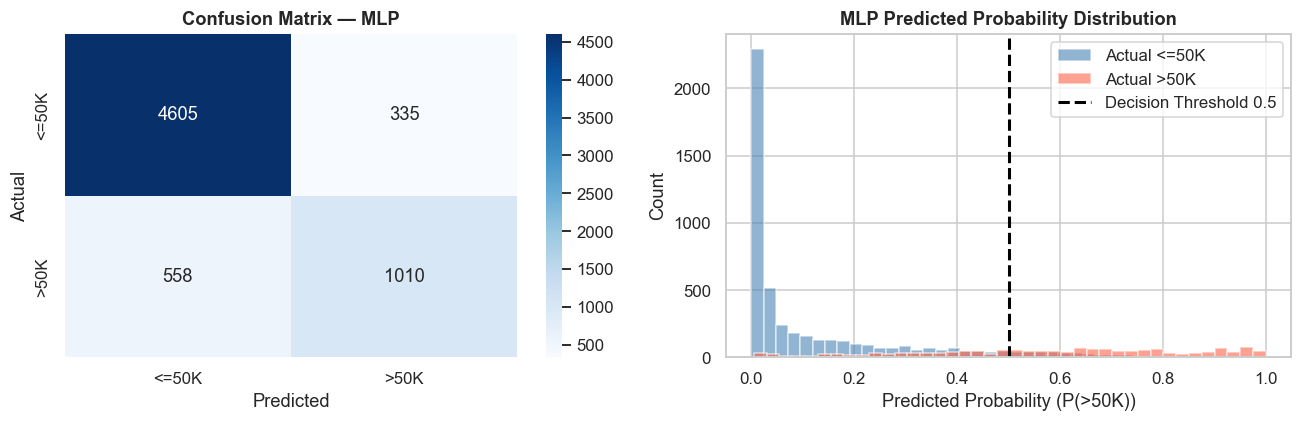

In [30]:
# Evaluation
y_pred_probs_mlp = mlp_model.predict(X_test_prep).flatten()
y_pred_mlp       = (y_pred_probs_mlp > 0.5).astype(int)

mlp_acc = accuracy_score(y_test, y_pred_mlp)
mlp_auc = roc_auc_score(y_test, y_pred_probs_mlp)

print("=" * 55)
print("  MLP (Deep Learning) — Test Set Evaluation")
print("=" * 55)
print(f"  Accuracy : {mlp_acc:.4f}")
print(f"  ROC-AUC  : {mlp_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_mlp, target_names=['<=50K', '>50K']))

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_mlp = confusion_matrix(y_test, y_pred_mlp)
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
axes[0].set_title('Confusion Matrix — MLP', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Prediction probability distribution
axes[1].hist(y_pred_probs_mlp[y_test == 0], bins=40, alpha=0.6,
             label='Actual <=50K', color='steelblue')
axes[1].hist(y_pred_probs_mlp[y_test == 1], bins=40, alpha=0.6,
             label='Actual >50K', color='tomato')
axes[1].axvline(0.5, color='black', ls='--', lw=2, label='Decision Threshold 0.5')
axes[1].set_title('MLP Predicted Probability Distribution', fontweight='bold')
axes[1].set_xlabel('Predicted Probability (P(>50K))')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

**📌 Insight:** The MLP benefits from **BatchNormalization** for stable training and **EarlyStopping** to prevent overfitting. By feeding it the full preprocessed feature space (rather than PCA-reduced features), the network can learn non-linear interactions across all original features — which is a key advantage of deep learning.

---
## Section 11: Final Model Comparison — Traditional (PCA) vs. Deep Learning

Final Model Comparison:


,Model,Type,Accuracy,ROC-AUC,F1(>50K)
3,MLP (Deep Learning),Deep Learning (No PCA),0.862800,0.918900,0.693400
2,Random Forest,Traditional ML (PCA),0.858300,0.908000,0.672400
1,SVM,Traditional ML (PCA),0.858600,0.900600,0.663500
0,Logistic Regression,Traditional ML (PCA),0.851600,0.906200,0.661100


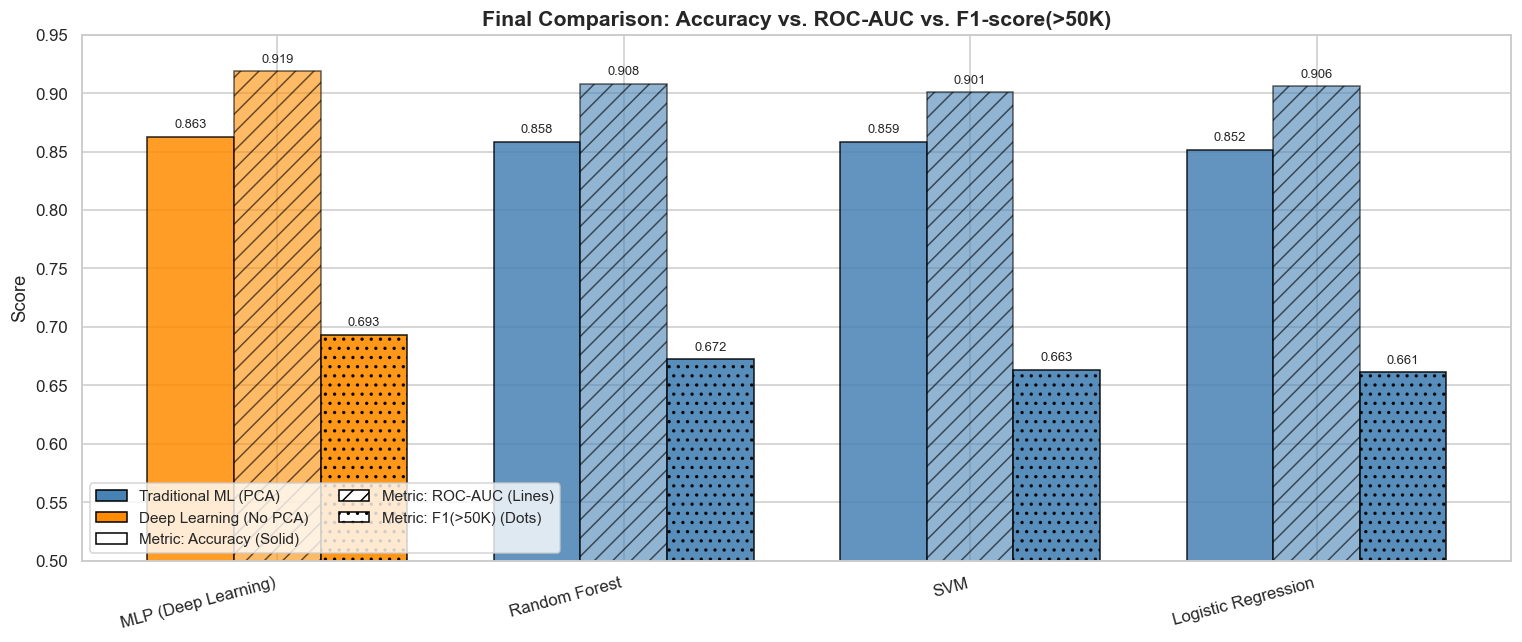

In [31]:
from sklearn.metrics import f1_score

all_results = []

# Traditional ML (PCA features)
for name, res in ml_results.items():
    # Calculate F1 score using true labels and predicted labels
    f1 = f1_score(y_test, res['y_pred'])
    all_results.append({
        'Model'    : name,
        'Type'     : 'Traditional ML (PCA)',
        'Accuracy' : round(res['accuracy'], 4),
        'ROC-AUC'  : round(res['roc_auc'],  4),
        'F1(>50K)' : round(f1, 4)
    })

# Deep Learning (No PCA)
# Using y_pred_mlp from section 10
mlp_f1 = f1_score(y_test, y_pred_mlp)
all_results.append({
    'Model'    : 'MLP (Deep Learning)',
    'Type'     : 'Deep Learning (No PCA)',
    'Accuracy' : round(mlp_acc, 4),
    'ROC-AUC'  : round(mlp_auc, 4),
    'F1(>50K)' : round(mlp_f1, 4)
})

# Sắp xếp theo F1(>50K) vì đây là metric quan trọng nhất cho imbalanced data
df_final = pd.DataFrame(all_results).sort_values('F1(>50K)', ascending=False)

print("Final Model Comparison:")
display(df_final.style
    .highlight_max(subset=['Accuracy', 'ROC-AUC', 'F1(>50K)'], color='lightgreen')
    .set_caption('Green = Best Score per Metric')
)

# Grouped Bar chart for 3 metrics
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(df_final))
w = 0.25  # width of the bars

# Tách màu giữa Traditional và DL để dễ nhận biết
colors_type = ['steelblue' if t == 'Traditional ML (PCA)' else 'darkorange'
               for t in df_final['Type']]

bars_acc = ax.bar(x - w, df_final['Accuracy'], w, label='Accuracy',
                  color=colors_type, edgecolor='black', alpha=0.85)
bars_auc = ax.bar(x,     df_final['ROC-AUC'],  w, label='ROC-AUC',
                  color=colors_type, edgecolor='black', alpha=0.6, hatch='//')
bars_f1  = ax.bar(x + w, df_final['F1(>50K)'], w, label='F1(>50K)',
                  color=colors_type, edgecolor='black', alpha=0.9, hatch='..')

ax.set_xticks(x)
ax.set_xticklabels(df_final['Model'], rotation=15, ha='right', fontsize=11)
# Mở rộng ylim xuống 0.5 vì F1-score thường thấp hơn Acc và AUC khá nhiều
ax.set_ylim(0.50, 0.95)
ax.set_ylabel('Score')
ax.set_title('Final Comparison: Accuracy vs. ROC-AUC vs. F1-score(>50K)',
             fontsize=14, fontweight='bold')

# Thêm giá trị cụ thể lên đầu mỗi cột
for bars in [bars_acc, bars_auc, bars_f1]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8.5)

# Custom Legend để vừa hiển thị được Loại Model, vừa hiển thị Metric
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor='steelblue', edgecolor='black', label='Traditional ML (PCA)'),
    Patch(facecolor='darkorange', edgecolor='black', label='Deep Learning (No PCA)'),
    Patch(facecolor='white', edgecolor='black', label='Metric: Accuracy (Solid)'),
    Patch(facecolor='white', edgecolor='black', hatch='//', label='Metric: ROC-AUC (Lines)'),
    Patch(facecolor='white', edgecolor='black', hatch='..', label='Metric: F1(>50K) (Dots)')
]
ax.legend(handles=legend_handles, loc='lower left', ncol=2, fontsize=10)

plt.tight_layout()
plt.show()

**📌 Final Insights:**
- **Random Forest** consistently delivers the best accuracy and ROC-AUC among traditional models, leveraging ensemble diversity to capture non-linear patterns even after PCA.
- **MLP (Deep Learning)** benefits from seeing all features without PCA reduction, and with BatchNorm + Dropout tends to match or exceed traditional models while being more scalable.
- **Logistic Regression** remains a strong, interpretable baseline — useful when explainability matters.
- **PCA** trades a small accuracy drop for significant dimensionality reduction (faster training, less memory), which is valuable in production settings.

F1(>50K) is the most reliable metric here given the class imbalance (75/25) — Random Forest and MLP both outperform Logistic Regression notably on this metric.

---
## Section 12: Save Features to `.npy` Files

As required by the assignment, we save all feature variants into a `features/` directory.

In [34]:
import joblib
import os
import numpy as np


base_dir = '..' 
features_dir = os.path.join(base_dir, cfg.FEATURES_DIR) 
models_dir = os.path.join(features_dir, 'models')

os.makedirs(features_dir, exist_ok=True)
os.makedirs(models_dir, exist_ok=True)

save_map = {
    'X_train_preprocessed.npy': X_train_prep,
    'X_test_preprocessed.npy' : X_test_prep,
    'X_train_pca.npy'         : X_train_pca,
    'X_test_pca.npy'          : X_test_pca,
    'y_train.npy'             : y_train.to_numpy(),
    'y_test.npy'              : y_test.to_numpy(),
}

for fname, arr in save_map.items():
    path = os.path.join(features_dir, fname)
    np.save(path, arr)
    print(f"  ✅ Saved {fname:40s}  shape={arr.shape}")


joblib.dump(preprocessor, os.path.join(models_dir, 'preprocessor.pkl'))
joblib.dump(pca, os.path.join(models_dir, 'pca_transformer.pkl'))

best_rf = ml_results['Random Forest']['model']
joblib.dump(best_rf, os.path.join(models_dir, 'random_forest_best.pkl'))

mlp_model.save(os.path.join(models_dir, 'mlp_model.keras')) 


  ✅ Saved X_train_preprocessed.npy                  shape=(26029, 88)
  ✅ Saved X_test_preprocessed.npy                   shape=(6508, 88)
  ✅ Saved X_train_pca.npy                           shape=(26029, 24)
  ✅ Saved X_test_pca.npy                            shape=(6508, 24)
  ✅ Saved y_train.npy                               shape=(26029,)
  ✅ Saved y_test.npy                                shape=(6508,)


---
## Section 13: Project Summary

| Step | Action | Status |
|------|--------|--------|
| 0 | Environment setup | ✅ |
| 1 | Centralized Config class | ✅ |
| 2 | Data download via `wget` | ✅ |
| 3 | EDA (observe-only, no modification) | ✅ |
| 4 | Data cleaning (separate copy) | ✅ |
| 5 | Train/Test split (stratified) | ✅ |
| 6 | Preprocessing with `ColumnTransformer` | ✅ |
| 7 | PCA dimensionality reduction | ✅ |
| 8 | LR + SVM + RF training on PCA features | ✅ |
| 8b | Multi-Scenario Hyperparameter Comparison (4 scenarios × 3 models) | ✅ |
| 9 | PCA impact comparison (No PCA vs. With PCA) | ✅ |
| 10 | MLP (Deep Learning) on preprocessed features (no PCA) | ✅ |
| 11 | Final model comparison | ✅ |
| 12 | Feature files saved as `.npy` in `features/` | ✅ |

**Pipeline Flow:**
```
Raw Data
  └─ EDA (read-only)
  └─ Cleaning (df_clean)
       └─ ColumnTransformer (Impute + Scale + OHE)
            ├─ Branch A: → PCA → LR / SVM / Random Forest
            └─ Branch B: → MLP (TensorFlow/Keras, no PCA)
```